In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data
telcom_data = pd.read_csv('/home/chethan/Documents/MONISH/machine_learning/chapter_1/Machine_Learning_Projects/chapter2/datasets/iranian+churn+dataset/Customer Churn.csv')

In [2]:
telcom_data.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [3]:
# Initial inspection
telcom_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   float64
 13  Churn                    3150 non-null   int64  
dtypes: float64(1), int64(13)

In [4]:
telcom_data.describe()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
count,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000
mean,7.627937,0.076508,32.541905,0.942857,4472.459683,69.460635,73.174921,23.509841,2.826032,1.077778,1.248254,30.998413,470.972916,0.157143
std,7.263886,0.265851,8.573482,1.521072,4197.908687,57.413308,112.237560,17.217337,0.892555,0.267864,0.432069,8.831095,517.015433,0.363993
min,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,15.000000,0.000000,0.000000
25%,1.000000,0.000000,30.000000,0.000000,1391.250000,27.000000,6.000000,10.000000,2.000000,1.000000,1.000000,25.000000,113.801250,0.000000
50%,6.000000,0.000000,35.000000,0.000000,2990.000000,54.000000,21.000000,21.000000,3.000000,1.000000,1.000000,30.000000,228.480000,0.000000
75%,12.000000,0.000000,38.000000,1.000000,6478.250000,95.000000,87.000000,34.000000,3.000000,1.000000,1.000000,30.000000,788.388750,0.000000
max,36.000000,1.000000,47.000000,10.000000,17090.000000,255.000000,522.000000,97.000000,5.000000,2.000000,2.000000,55.000000,2165.280000,1.000000


In [5]:
telcom_data.isnull().sum()

Call  Failure              0
Complains                  0
Subscription  Length       0
Charge  Amount             0
Seconds of Use             0
Frequency of use           0
Frequency of SMS           0
Distinct Called Numbers    0
Age Group                  0
Tariff Plan                0
Status                     0
Age                        0
Customer Value             0
Churn                      0
dtype: int64

In [6]:
# Check for duplicates
print("Number of duplicates:", telcom_data.duplicated().sum())

# Remove duplicates
telcom_data = telcom_data.drop_duplicates()

Number of duplicates: 300


In [7]:
telcom_data.shape

(2850, 14)

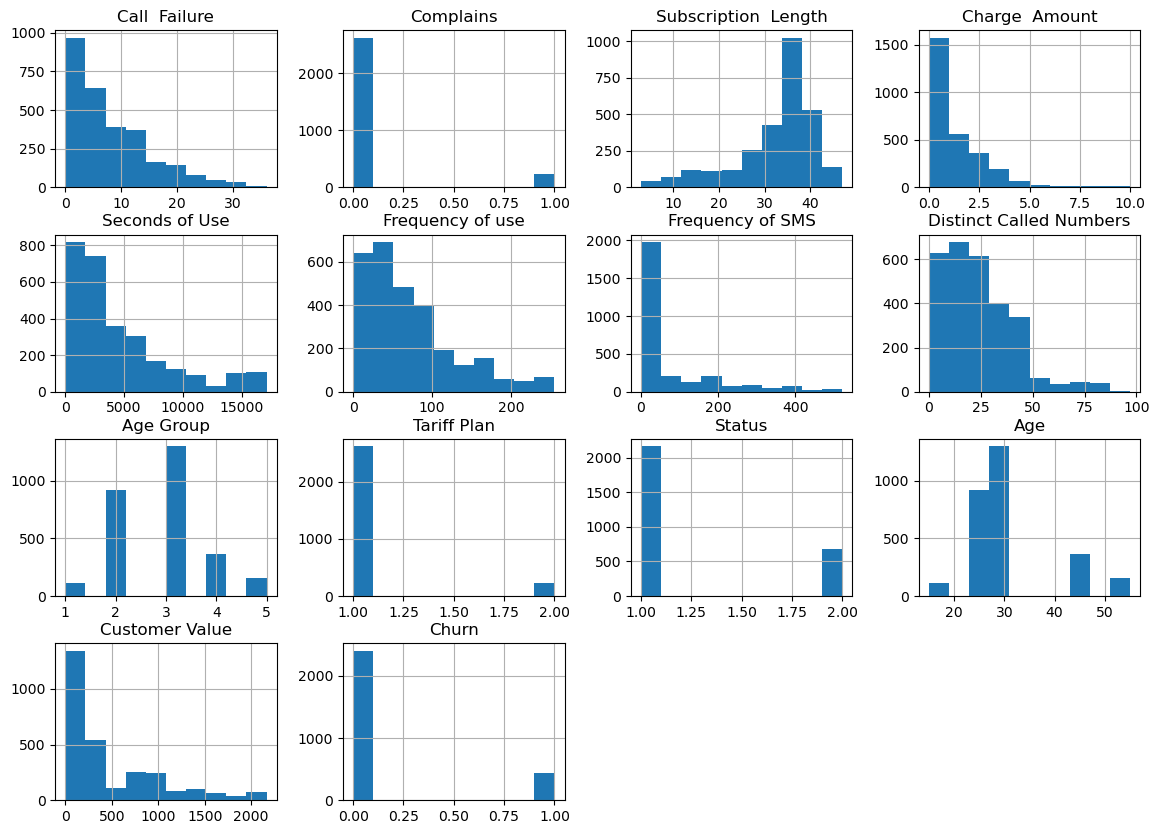

In [8]:
telcom_data.hist(grid=True , figsize=(14,10))
plt.show()

In [9]:
telcom_data.corrwith(telcom_data["Customer Value"]).sort_values(ascending=False)

Customer Value             1.000000
Frequency of SMS           0.922852
Seconds of Use             0.408536
Frequency of use           0.394647
Distinct Called Numbers    0.275447
Tariff Plan                0.249999
Charge  Amount             0.161852
Subscription  Length       0.113184
Call  Failure              0.110228
Complains                 -0.136989
Age Group                 -0.193461
Age                       -0.227174
Churn                     -0.287078
Status                    -0.403568
dtype: float64

#### Never use highly correlated features

In [10]:
telcom_data.drop(columns=["Frequency of SMS"] , inplace=True)

In [11]:
# import seaborn as sns
# plt.figure(figsize=(12, 8))
# sns.heatmap(telcom_data.select_dtypes(include=[np.number]), annot=True, cmap='coolwarm', fmt='.2f')
# plt.title("Heatmap of Numerical Data")
# plt.show()

#### there are features that are highly imbalanced such as 
#### "Complains",'Tariff Plan', 'Status',"Churn"


##### - for this you need to use over sampling or under sampling or both to get better results 

In [12]:
##ill do later

In [13]:
telcom_data.columns

Index(['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount',
       'Seconds of Use', 'Frequency of use', 'Distinct Called Numbers',
       'Age Group', 'Tariff Plan', 'Status', 'Age', 'Customer Value', 'Churn'],
      dtype='object')

In [14]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.kernel_approximation import RBFSampler
from sklearn.base import BaseEstimator , TransformerMixin
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [15]:
class CustomFunctionTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, func=None, inverse_func=None, feature_names_out=None):
        self.func = func
        self.inverse_func = inverse_func
        self.feature_names_out = feature_names_out

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return self.func(X)

    def inverse_transform(self, X):
        return self.inverse_func(X)

    def get_feature_names_out(self, input_features=None):
        return input_features if self.feature_names_out is None else self.feature_names_out

In [16]:

class RBFFeatureTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, gamma=None):
        self.gamma = gamma
        self.rbf_sampler = None

    def fit(self, X, y=None):
        self.rbf_sampler = RBFSampler(gamma=self.gamma)
        self.rbf_sampler.fit(X)
        return self

    def transform(self, X):
        return self.rbf_sampler.transform(X)

In [17]:
# Define the pipelines
log_pipeline = make_pipeline(
    SimpleImputer(strategy="mean"),
    CustomFunctionTransformer(np.log1p, np.expm1, feature_names_out="one-to-one"),
    StandardScaler()
)

num_pipeline = make_pipeline(
    SimpleImputer(strategy="mean"),
    RBFFeatureTransformer(gamma=0.02),  # Using the custom RBF kernel transformer
    StandardScaler()
)

# Define the preprocessing pipeline
preprocessing = ColumnTransformer([
    ("log", log_pipeline, ["Seconds of Use"]),
    ("num", num_pipeline, ['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount',
                           'Frequency of use', 'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age', 'Churn']),
])

preprocessing

ColumnTransformer(transformers=[('log',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer()),
                                                 ('customfunctiontransformer',
                                                  CustomFunctionTransformer(feature_names_out='one-to-one',
                                                                            func=<ufunc 'log1p'>,
                                                                            inverse_func=<ufunc 'expm1'>)),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['Seconds of Use']),
                                ('num',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer()),
                                                 ('rbffeaturetransformer',
                                                  RBFFeatureTransformer(gamma=0.02)),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['Call  Failure', 'Complains',
                                  'Subscription  Length', 'Charge  Amount',
                                  'Frequency of use', 'Distinct Called Numbers',
                                  'Age Group', 'Tariff Plan', 'Status', 'Age',
                                  'Churn'])])

In [18]:
from sklearn.model_selection import train_test_split

train_set , test_set = train_test_split(telcom_data , test_size=0.3 , random_state=30)
# X_train = preprocessing.fit_transform(train_set.drop(columns=["Customer Value"]))
# y_train = train_set["Customer Value"].copy()


In [19]:
X_train = train_set.drop(columns=["Customer Value"] , axis=1)
X_train

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Churn
1589,0,0,24,0,663,23,51,4,1,1,45,0
1061,4,0,36,0,1933,48,15,3,1,2,30,0
1202,6,0,39,0,2228,56,26,2,1,1,25,0
2601,5,0,41,0,305,6,2,3,1,2,30,0
2509,10,0,37,2,4640,81,22,3,1,1,30,0
...,...,...,...,...,...,...,...,...,...,...,...,...
924,7,0,35,0,5108,87,24,2,1,1,25,1
1258,1,0,32,0,13388,161,38,3,1,1,30,0
500,4,0,38,0,3770,61,2,2,1,1,25,0
421,6,0,34,1,6538,67,32,2,1,1,25,0


In [20]:
y_train  = train_set["Customer Value"].copy()
y_train

1589      22.150
1061      83.240
1202    1731.780
2601      40.440
2509     216.840
          ...   
924      238.275
1258     541.960
500      172.395
421      733.725
1941      86.125
Name: Customer Value, Length: 1995, dtype: float64

In [22]:
X_test = test_set.drop(columns=["Customer Value"])
y_test = test_set["Customer Value"].copy()

# X_test = preprocessing.transform(X_test)
# # Predict

In [23]:

# Fit the preprocessing pipeline on X_train
X_train_transformed = preprocessing.fit_transform(X_train)

# Transform the X_test data
X_test_transformed = preprocessing.transform(X_test)

print(f"Shape of X_train_transformed: {X_train_transformed.shape}")
print(f"Shape of X_test_transformed: {X_test_transformed.shape}")

Shape of X_train_transformed: (1995, 101)
Shape of X_test_transformed: (855, 101)


In [24]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing , LinearRegression())

lin_reg.fit(X= X_train, y=y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('log',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('customfunctiontransformer',
                                                                   CustomFunctionTransformer(feature_names_out='one-to-one',
                                                                                             func=<ufunc 'log1p'>,
                                                                                             inverse_func=<ufunc 'expm1'>)),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['Seconds of Use']),
                                                 ('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('rbffeaturetransformer',
                                                                   RBFFeatureTransformer(gamma=0.02)),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['Call  Failure', 'Complains',
                                                   'Subscription  Length',
                                                   'Charge  Amount',
                                                   'Frequency of use',
                                                   'Distinct Called Numbers',
                                                   'Age Group', 'Tariff Plan',
                                                   'Status', 'Age',
                                                   'Churn'])])),
                ('linearregression', LinearRegression())])

In [25]:
y_pred = lin_reg.predict(X_test)

In [26]:
y_pred

array([ 6.93520398e+02,  5.49912489e+02,  8.73476056e+02, -4.34547168e+02,
        1.08739338e+03,  1.13567856e+01,  6.13980278e+01,  1.14783842e+03,
        3.20561921e+02,  7.02607876e+02,  7.50083594e+02,  9.37841574e+01,
        1.76634301e+02,  2.23288156e+02,  4.43961407e+02,  5.76141468e+01,
        5.60156744e+02,  9.98656329e+02, -5.79897903e+01,  1.41763360e+02,
        7.21304330e+02,  7.34386402e+02,  2.33176778e+02,  8.64728003e+02,
        8.35703125e+02,  7.38162774e+02, -4.76391098e+01,  2.35929551e+02,
        4.59379708e+02,  4.77511760e+02,  2.63051229e+02,  7.18240314e+02,
        8.52561191e+02,  4.22053001e+02,  6.29662273e+02,  3.11937360e+02,
        5.21265865e+02,  2.92404227e+02,  9.11871233e+02,  1.02586300e+03,
        5.02293463e+02,  1.06253247e+03,  3.53030086e+02,  4.26609232e+02,
        2.73633131e+02,  8.09728059e+02,  3.77546926e+02,  6.58258468e+02,
        5.49015698e+02,  3.47788468e+02,  2.98473117e+02,  1.08981835e+03,
        1.19274598e+03,  

In [27]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print the metrics
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

Mean Absolute Error (MAE): 321.76
Mean Squared Error (MSE): 176788.98
Root Mean Squared Error (RMSE): 420.46
R-squared (R²): 0.31


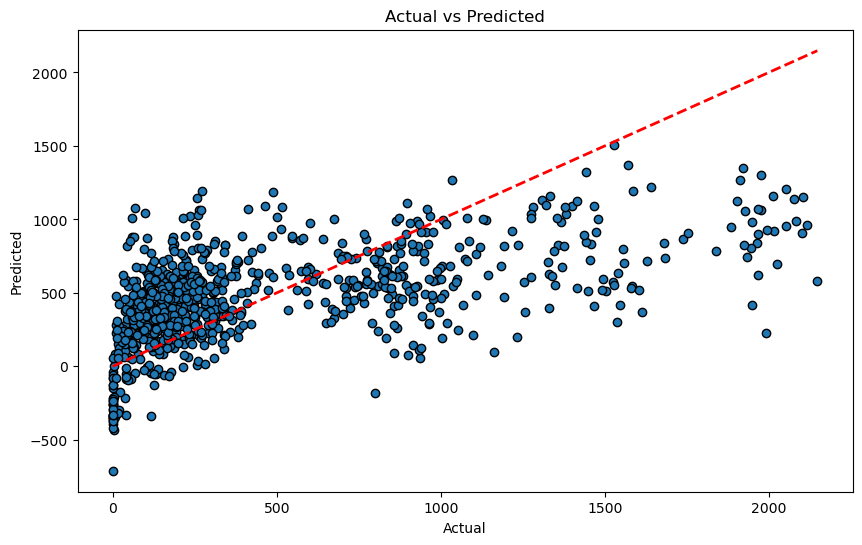

In [28]:
# Plotting predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, edgecolors=(0, 0, 0))
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

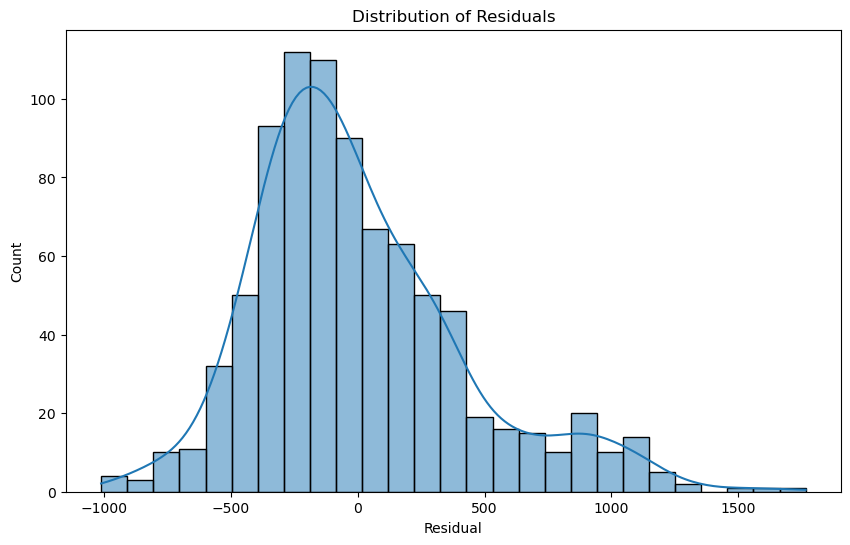

In [29]:
import seaborn as sns
# Distribution of residuals
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residual')
plt.title('Distribution of Residuals')
plt.show()

#### let us try building some other regression models

#### - DecisionTree Regressor

In [44]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing , DecisionTreeRegressor(criterion='squared_error',splitter='best' , max_depth=8 , max_features=20))

tree_reg.fit(X=X_train , y=y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('log',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('customfunctiontransformer',
                                                                   CustomFunctionTransformer(feature_names_out='one-to-one',
                                                                                             func=<ufunc 'log1p'>,
                                                                                             inverse_func=<ufunc 'expm1'>)),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['Seconds of Use']),
                                                 ('num',
                                                  Pipeline(steps=[('simplei...,
                                                                   SimpleImputer()),
                                                                  ('rbffeaturetransformer',
                                                                   RBFFeatureTransformer(gamma=0.02)),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['Call  Failure', 'Complains',
                                                   'Subscription  Length',
                                                   'Charge  Amount',
                                                   'Frequency of use',
                                                   'Distinct Called Numbers',
                                                   'Age Group', 'Tariff Plan',
                                                   'Status', 'Age',
                                                   'Churn'])])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(max_depth=8, max_features=20))])

In [45]:
tree_pred = tree_reg.predict(X=X_test)

In [46]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, tree_pred)
mse = mean_squared_error(y_test, tree_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, tree_pred)

# Print the metrics
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

Mean Absolute Error (MAE): 240.85
Mean Squared Error (MSE): 196719.15
Root Mean Squared Error (RMSE): 443.53
R-squared (R²): 0.23


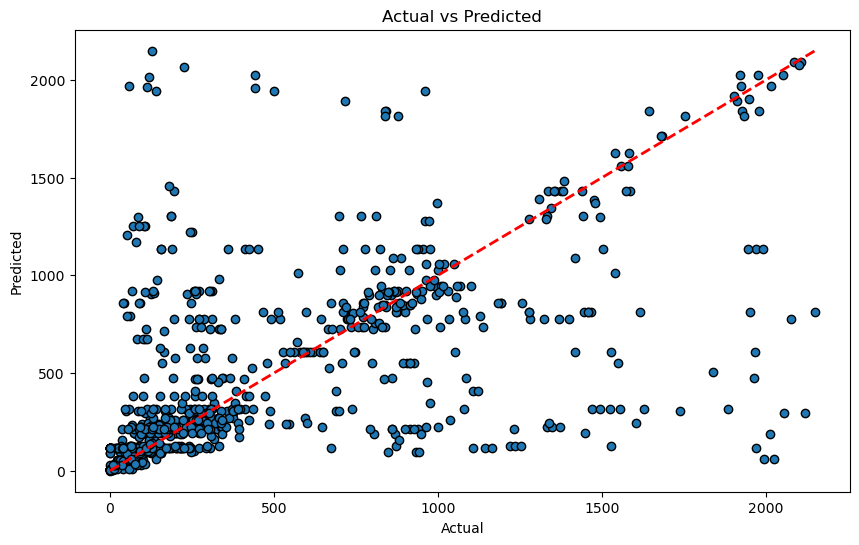

In [47]:
# Plotting predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, tree_pred, edgecolors=(0, 0, 0))
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

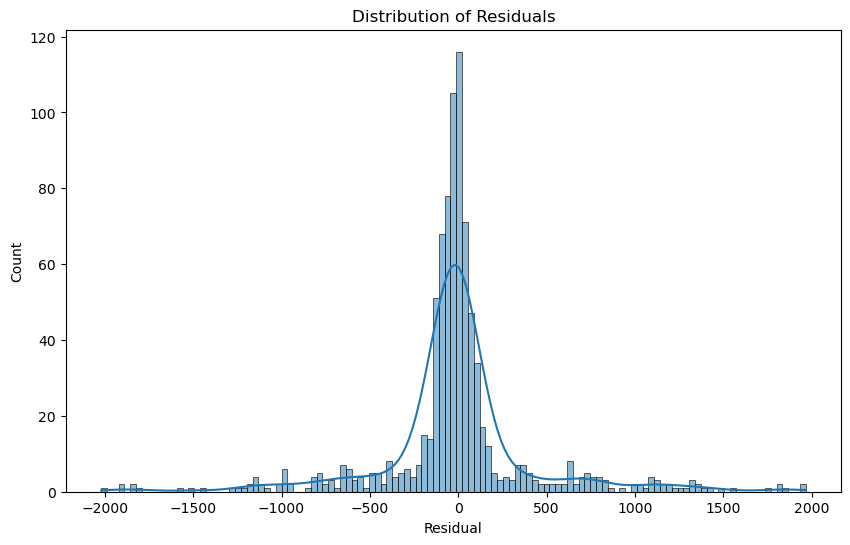

In [48]:
import seaborn as sns
# Distribution of residuals
residuals = y_test - tree_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residual')
plt.title('Distribution of Residuals')
plt.show()

##### - lets try RandomForest Regressor

In [49]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing , RandomForestRegressor(criterion='poisson',max_depth=8 , max_features=20 , random_state=42))

forest_reg.fit(X=X_train , y = y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('log',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('customfunctiontransformer',
                                                                   CustomFunctionTransformer(feature_names_out='one-to-one',
                                                                                             func=<ufunc 'log1p'>,
                                                                                             inverse_func=<ufunc 'expm1'>)),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['Seconds of Use']),
                                                 ('num',
                                                  Pipeline(steps=[('simplei...
                                                                  ('rbffeaturetransformer',
                                                                   RBFFeatureTransformer(gamma=0.02)),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['Call  Failure', 'Complains',
                                                   'Subscription  Length',
                                                   'Charge  Amount',
                                                   'Frequency of use',
                                                   'Distinct Called Numbers',
                                                   'Age Group', 'Tariff Plan',
                                                   'Status', 'Age',
                                                   'Churn'])])),
                ('randomforestregressor',
                 RandomForestRegressor(criterion='poisson', max_depth=8,
                                       max_features=20, random_state=42))])

In [50]:
forest_pred = forest_reg.predict(X=X_test)

In [51]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, forest_pred)
mse = mean_squared_error(y_test, forest_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, forest_pred)

# Print the metrics
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

Mean Absolute Error (MAE): 246.82
Mean Squared Error (MSE): 115867.90
Root Mean Squared Error (RMSE): 340.39
R-squared (R²): 0.55


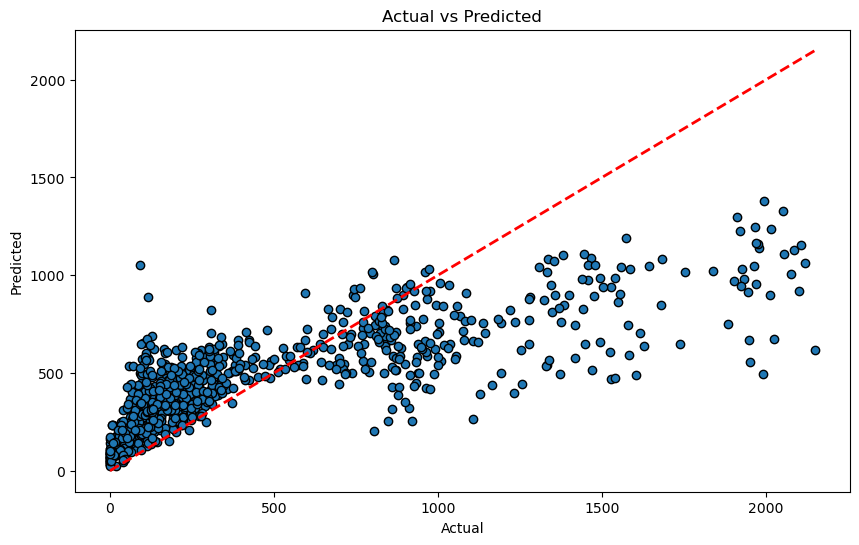

In [52]:
# Plotting predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, forest_pred, edgecolors=(0, 0, 0))
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

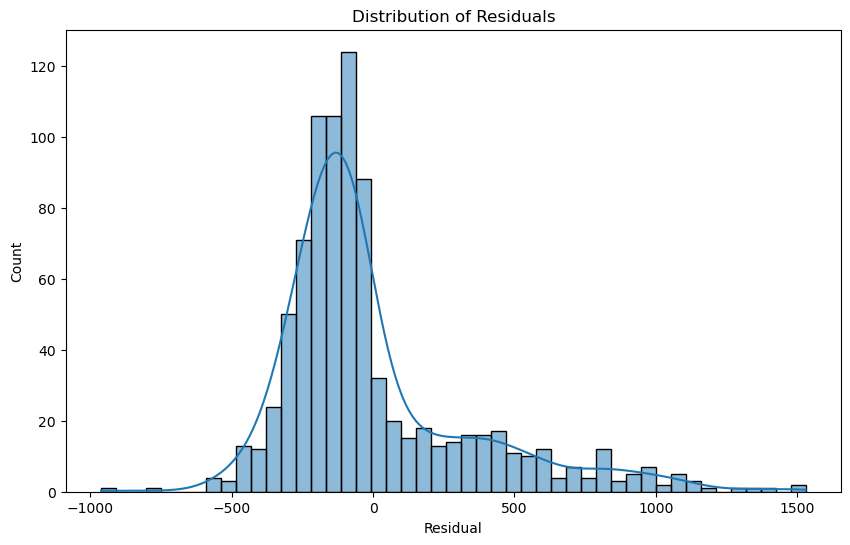

In [53]:
import seaborn as sns
# Distribution of residuals
residuals = y_test - forest_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residual')
plt.title('Distribution of Residuals')
plt.show()

##### the model fine tuning will be done in the later tutorial